# Evaluate and demo the SMS malicious-message classifier

This notebook evaluates the saved DistilBERT model on the held-out test set.

We evaluate on the test set because these examples were not used for training or
model selection. This gives a more honest estimate of how the model may perform
on new SMS messages.

We evaluate on the held-out test set because these examples were not used for
training or model selection. This gives a more honest estimate of how the model
may perform on new SMS messages.

In [2]:
from pathlib import Path

import pandas as pd
from transformers import AutoModelForSequenceClassification, AutoTokenizer

from sms_classifier.labels import LABEL_TO_ID

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models" / "distilbert-sms"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

test_df = pd.read_csv(DATA_DIR / "test.csv")

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)

test_df["label_id"] = test_df["label"].map(LABEL_TO_ID)

print(test_df.shape)
print(test_df["label"].value_counts())
test_df.head()

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 11553.94it/s]

(1115, 3)
label
benign       966
malicious    149
Name: count, dtype: int64


,message,label,label_id
0,No message..no responce..what happend?\r\n,benign,0
1,At WHAT TIME should i come tomorrow\r\n,benign,0
2,Come to my home for one last time i wont do an...,benign,0
3,Get ur 1st RINGTONE FREE NOW! Reply to this ms...,malicious,1
4,See you there! \r\n,benign,0


## Generate predictions on the test set

We reuse Hugging Face's `Trainer` for evaluation even though we are not training.
The `Trainer.predict()` method handles the same practical details as training:
batching examples, padding each batch, moving tensors to the right device, and
collecting model outputs.

`TrainingArguments` is still required because `Trainer` uses it as its runtime
configuration object. In this notebook, it controls evaluation-time settings such
as batch size, output directory, and disabling external experiment reporting.

In [4]:
import numpy as np
from transformers import DataCollatorWithPadding, Trainer, TrainingArguments

from sms_classifier.model import dataframe_to_dataset, tokenize_messages

test_dataset = dataframe_to_dataset(test_df[["message", "label"]])

# Tokenize the raw SMS text into model inputs such as `input_ids` and
# `attention_mask`.
tokenized_test_dataset = test_dataset.map(
    lambda examples: tokenize_messages(examples, tokenizer), batched=True
)

test_features = tokenized_test_dataset.remove_columns(["message", "label"])

# SMS messages have different token lengths.
# This collator pads each batch dynamically, instead of padding every message
# to the maximum length ahead of time.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# `TrainingArguments` is still used during evaluation because `Trainer` expects
# one shared configuration object for training, evaluation, and prediction.
# Here, we are not training; these settings mainly control prediction batch size,
# temporary output location, and external reporting.
prediction_arguments = TrainingArguments(
    output_dir=str(PROJECT_ROOT / "models" / "evaluation-output"),
    per_device_eval_batch_size=16,
    report_to="none",
)

# Reusing `Trainer` keeps evaluation consistent with training and avoids writing
# a manual PyTorch loop for batching, padding, device placement, and output
# collection.
trainer = Trainer(
    model=model,
    args=prediction_arguments,
    processing_class=tokenizer,
    data_collator=data_collator,
)

prediction_output = trainer.predict(test_features)

logits = prediction_output.predictions

# `label_ids` are the correct numeric labels from the test set.
true_labels = prediction_output.label_ids

# Pick the class with the highest logit for each message.
predicted_labels = np.argmax(logits, axis=-1)

print(logits.shape)
print(true_labels[:10])
print(predicted_labels[:10])

Map: 100%|██████████| 1115/1115 [00:00<00:00, 48488.31 examples/s]


[[ 3.0272372 -3.307363 ]
 [ 2.9568355 -3.2164507]
 [ 2.990916  -3.2770858]
 [-2.2570825  2.4487257]
 [ 2.65599   -3.0099292]
 [ 2.9627893 -3.2539496]
 [-2.0415132  2.2014215]
 [ 2.673205  -2.983906 ]
 [ 3.0560832 -3.3920517]
 [ 2.9683602 -3.3138318]]
(1115, 2)
[0 0 0 1 0 0 1 0 0 0]
[0 0 0 1 0 0 1 0 0 0]


## Compute evaluation metrics

Accuracy shows the overall share of correct predictions. For this project, we also
track malicious-message precision, recall, and F1 because malicious messages are
the safety-relevant class.

Recall is especially important here: a false negative means the model missed a
message that was actually malicious.

In [5]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

accuracy = accuracy_score(true_labels, predicted_labels)

precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels,
    predicted_labels,
    average="binary",
    pos_label=LABEL_TO_ID["malicious"],
)

metrics = {
    "accuracy": float(accuracy),
    "malicious_precision": float(precision),
    "malicious_recall": float(recall),
    "malicious_f1": float(f1),
}

metrics

{'accuracy': 0.989237668161435,
 'malicious_precision': 0.9724137931034482,
 'malicious_recall': 0.9463087248322147,
 'malicious_f1': 0.9591836734693877}

## Confusion matrix

The confusion matrix shows counts of correct and incorrect predictions. For this
project, the most important error type is a false negative: a truly malicious
message predicted as benign.

In [6]:
from sklearn.metrics import confusion_matrix

label_names = ["benign", "malicious"]

confusion = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=[LABEL_TO_ID["benign"], LABEL_TO_ID["malicious"]],
)

confusion

array([[962,   4],
       [  8, 141]])

WindowsPath('C:/Users/giloz/dev/sms-malicious-classifier/reports/figures/confusion_matrix.png')

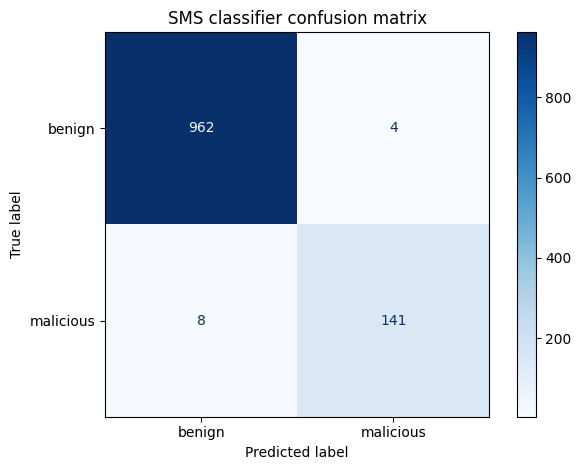

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=label_names,
)

display.plot(cmap="Blues", values_format="d")
plt.title("SMS classifier confusion matrix")
plt.tight_layout()

confusion_matrix_path = FIGURES_DIR / "confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=150, bbox_inches="tight")

confusion_matrix_path

## Save evaluation artifacts

The notebook saves metrics and plots so the evaluation results can be reviewed
without rerunning every cell.

In [9]:
import json

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = REPORTS_DIR / "metrics.json"

with metrics_path.open("w", encoding="utf-8") as file:
    json.dump(metrics, file, indent=2)

metrics_path

WindowsPath('C:/Users/giloz/dev/sms-malicious-classifier/reports/metrics.json')

In [10]:
metrics_path.read_text(encoding="utf-8")

'{\n  "accuracy": 0.989237668161435,\n  "malicious_precision": 0.9724137931034482,\n  "malicious_recall": 0.9463087248322147,\n  "malicious_f1": 0.9591836734693877\n}'

## Interpret the results

On the held-out test set, the model reached about 98.9% accuracy. Its malicious
precision was about 97.2%, meaning that when it predicted `malicious`, it was
usually correct.

The most important safety-aware metric is malicious recall: about 94.6%. This
means the model caught most malicious messages, but not all of them.

From the confusion matrix, the model missed 8 malicious messages by predicting
them as benign. These false negatives matter because a missed malicious SMS could
still reach a user and lead to spam, phishing, or other harmful behavior.

Accuracy alone is not enough for this task because the dataset contains many more
benign messages than malicious ones. A safety-focused evaluation should always
look closely at malicious-message recall and false negatives.

## Limitations

This evaluation uses an SMS spam dataset as a proxy for malicious-message
classification. Real-world malicious SMS messages may include newer phishing
patterns, social engineering tactics, shortened links, impersonation, or language
styles that are not fully represented here.

Because of that, these metrics should be treated as evidence that the model works
on this benchmark, not proof that it is ready for production safety decisions.
A real deployment would need fresher data, more diverse malicious examples, and
ongoing monitoring for missed malicious messages.